# Imports

In [1]:
import pandas as pd
import numpy as np

# Get and Format Data

In [2]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [3]:
sweden_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/boreal/sweden_train_{year}.csv"), year) for year in range(2022, 2025)]
sweden_train = pd.concat(sweden_train_sets, axis=0)

quebec_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/boreal/quebec_train_{year}.csv"), year) for year in range(2022, 2025)]
quebec_train = pd.concat(quebec_train_sets, axis=0)

siberia_train_sets = [prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/boreal/siberia_train_{year}.csv"), year) for year in range(2022, 2025)]
siberia_train = pd.concat(siberia_train_sets, axis=0)

train_set = pd.concat([sweden_train, quebec_train, siberia_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year')
print(train_set.head())
# print(train_set.groupby('year')['class'].count())

     system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
3071       2_71_0       -0.217100  0.245903        -0.193337   0.236790   
5658     2_2658_0        0.003224  0.272757        -0.006519   0.179046   
4561     2_1561_0       -0.010161  0.286890        -0.008172   0.218877   
1415     1_4415_0        0.044919  0.240684        -0.011017   0.113844   
4765     2_1765_0       -0.005323  0.308305        -0.049467   0.244428   

      NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  \
3071         0.185026   0.199349          -14688.0     10328.0   
5658         0.010269   0.309458              58.5      8166.0   
4561        -0.003694   0.304764             110.0      8209.0   
1415         0.139605   0.309081           -2446.0      9406.0   
4765         0.088780   0.338219           -1955.5      8082.5   

      SR_B5_delta_lag4  ...  NDVI_lag0  SR_B4_lag0  SR_B5_lag0  SR_B6_lag0  \
3071          -10272.0  ...   0.014323     25016.0     25743.0     10258.0

In [4]:
print(len(train_set))

54000


In [5]:
all_features = train_set.columns.drop(['year', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'])

recent_features = ['NBR_delta_lag1', 'NBR_lag1',
       'NDMI_delta_lag1', 'NDMI_lag1', 'NDVI_delta_lag1', 'NDVI_lag1',
       'SR_B4_delta_lag1', 'SR_B4_lag1', 'SR_B5_delta_lag1', 'SR_B5_lag1',
       'SR_B6_delta_lag1', 'SR_B6_lag1', 'SR_B7_delta_lag1', 'SR_B7_lag1',
       'NBR_lag0', 'NDMI_lag0', 'NDVI_lag0', 'SR_B4_lag0', 'SR_B5_lag0',
       'SR_B6_lag0', 'SR_B7_lag0']

In [6]:
from sklearn.model_selection import train_test_split

X = train_set[recent_features]
y = train_set['class']


# Evaluate Model on Training Data via Nested-CV

In [7]:
def custom_year_ts_split(df, year_col):
    """Custom CV splitter for our yearly data."""
    # Get unique years and sort them
    years = sorted(df[year_col].unique())
    
    # We need at least 2 years to do one split (Train Y1 -> Val Y2)
    for i in range(1, len(years)):
        # Training set: All years up to the current split
        train_indices = df[df[year_col].isin(years[:i])].index.values
        
        # Validation set: The very next year
        val_indices = df[df[year_col] == years[i]].index.values
        yield train_indices, val_indices

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate


In [9]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

In [10]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer(1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [11]:
xgb_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))
])

tuner = BayesSearchCV(
    estimator=xgb_pipe,
    cv=5,
    n_iter=32,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1',
)

cv_iterator = custom_year_ts_split(train_set, 'year')

xgb_results = cross_validate(
    tuner,
    X, 
    y, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [12]:
# Print inner-CV (5-fold) average train/test scores for each outer fold (using best inner params)
for outer_fold, outer_estimator in enumerate(xgb_results['estimator'], start=1):
    search = outer_estimator.named_steps['model'] if hasattr(outer_estimator, "named_steps") else outer_estimator
    inner_results = pd.DataFrame(search.cv_results_)
    best_idx = search.best_index_

    print(f"Outer Fold {outer_fold} Parameters - {search.best_params_}")
    mean_test = inner_results.loc[best_idx, "mean_test_score"]
    std_test = inner_results.loc[best_idx, "std_test_score"]
    print(f"Outer Fold {outer_fold} - Inner Mean Test Score:  {mean_test:.6f}")
    print(f"Outer Fold {outer_fold} - Inner Test Score STD:  {std_test:.6f}")

    if "mean_train_score" in inner_results.columns:
        mean_train = inner_results.loc[best_idx, "mean_train_score"]
        std_train = inner_results.loc[best_idx, "std_train_score"]
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: {mean_train:.6f}")
        print(f"Outer Fold {outer_fold} - Inner Train Score STD:  {std_test:.6f}")
    else:
        print(f"Outer Fold {outer_fold} - Inner Mean Train Score: not available (set return_train_score=True in BayesSearchCV)")

print('\nOverall Metrics')
print(f"Mean Test f1: {xgb_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {xgb_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {xgb_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {xgb_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {xgb_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {xgb_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-xgb_results['test_f1'].mean()/xgb_results['train_f1'].mean()}")

Outer Fold 1 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 0.7})
Outer Fold 1 - Inner Mean Test Score:  0.984372
Outer Fold 1 - Inner Test Score STD:  0.001650
Outer Fold 1 - Inner Mean Train Score: 0.997552
Outer Fold 1 - Inner Train Score STD:  0.001650
Outer Fold 2 Parameters - OrderedDict({'model__colsample_bylevel': 1.0, 'model__colsample_bynode': 1.0, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 0.0, 'model__reg_lambda': 0.0, 'model__subsample': 0.7})
Outer Fold 2 - Inner Mean Test Score:  0.997315
Outer Fold 2 - Inner Test Score STD:  0.001293
Outer Fold 2 - Inner Mean Train Score: 0.998680
Outer Fold 2 - Inner Train Score STD:  0.001293

Overall Metrics
Mean Test f1: 0.99892091
Mean Test Precision: 0.99966777
Mean Test Recall: 0.99817518
Mean Train f1: 0.99892091
Mean Train Precision:

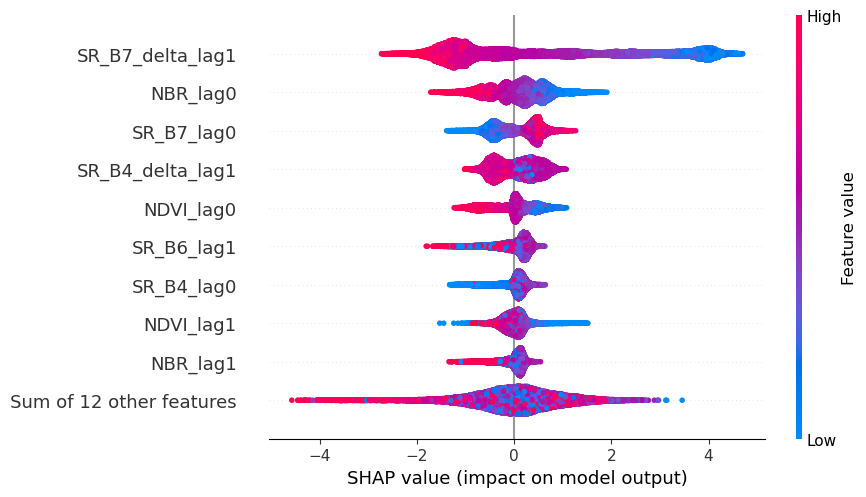

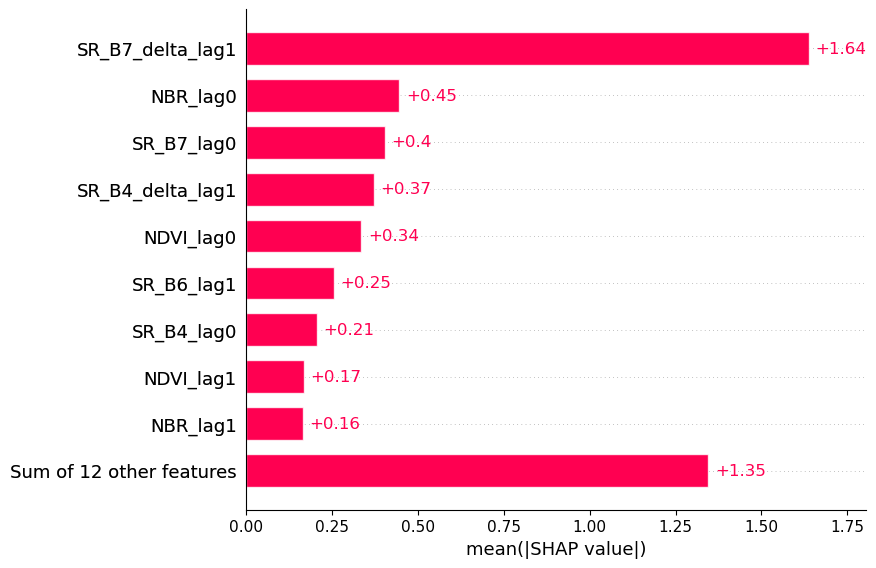

In [13]:
import shap
# Re-fit the tuner on full training data to get a final best estimator for interpretation
tuner.fit(X, y)
best_pipe = tuner.best_estimator_
model = best_pipe.named_steps['model']
explainer = shap.Explainer(model)
# Transform training data for the model component
X_trans = pd.DataFrame(
    best_pipe.named_steps['transformer'].transform(X),
    columns=recent_features,
    index=X.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


# Train Model

In [14]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)

In [15]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

In [16]:
xgboost_param_grid = {
    'model__max_depth': Integer(3, 5),
    'model__min_child_weight': Integer (1, 200),
    'model__subsample': Real(0.7, 1),
    'model__colsample_bylevel': Real(0.5, 1),
    'model__colsample_bynode': Real(0.5, 1),
    'model__reg_lambda': Real(0, 10),
    'model__reg_alpha': Real(0, 10)
}

In [17]:
stage_1_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'))])

tuner = BayesSearchCV(
    estimator=stage_1_pipe,
    cv=5,
    refit='f1',
    search_spaces=xgboost_param_grid,
    return_train_score=True,
    random_state=1,
    scoring='f1'
)

In [18]:
tuner.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'model__colsample_bylevel': Real(low=0.5,...m='normalize'), 'model__colsample_bynode': Real(low=0.5,...m='normalize'), 'model__max_depth': Integer(low=3...m='normalize'), 'model__min_child_weight': Integer(low=1...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'f1'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,'f1'
,cv,5


In [19]:
print(tuner.best_params_)
params = {k.replace('model__', ''): v for k, v in tuner.best_params_.items()}


OrderedDict({'model__colsample_bylevel': 0.9932897112418444, 'model__colsample_bynode': 0.92754877262305, 'model__max_depth': 5, 'model__min_child_weight': 1, 'model__reg_alpha': 7.909747275585786, 'model__reg_lambda': 9.060816989813638, 'model__subsample': 0.9734847260950075})


In [20]:
stage_2_transformer = PowerTransformer('yeo-johnson')
stage_2_model = XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, early_stopping_rounds=50, eval_metric="logloss", tree_method='hist')

In [21]:
X_train_stage2 = stage_2_transformer.fit_transform(X_train)
X_val_stage2 = stage_2_transformer.transform(X_val)

stage_2_model.fit(
    X_train_stage2, y_train,
    eval_set=[(X_val_stage2, y_val)], # Required for early stopping
    verbose=True,                     # Shows progress
)

[0]	validation_0-logloss:0.69260
[1]	validation_0-logloss:0.69206
[2]	validation_0-logloss:0.69152
[3]	validation_0-logloss:0.69098
[4]	validation_0-logloss:0.69043
[5]	validation_0-logloss:0.68989
[6]	validation_0-logloss:0.68936
[7]	validation_0-logloss:0.68883
[8]	validation_0-logloss:0.68829
[9]	validation_0-logloss:0.68776
[10]	validation_0-logloss:0.68723
[11]	validation_0-logloss:0.68669
[12]	validation_0-logloss:0.68616
[13]	validation_0-logloss:0.68563
[14]	validation_0-logloss:0.68510
[15]	validation_0-logloss:0.68457
[16]	validation_0-logloss:0.68405
[17]	validation_0-logloss:0.68352
[18]	validation_0-logloss:0.68300
[19]	validation_0-logloss:0.68248
[20]	validation_0-logloss:0.68196
[21]	validation_0-logloss:0.68143
[22]	validation_0-logloss:0.68091
[23]	validation_0-logloss:0.68040
[24]	validation_0-logloss:0.67988
[25]	validation_0-logloss:0.67936
[26]	validation_0-logloss:0.67884
[27]	validation_0-logloss:0.67832
[28]	validation_0-logloss:0.67781
[29]	validation_0-loglos

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,0.9932897112418444
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,0.92754877262305
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb

In [22]:
best_round = stage_2_model.best_iteration
print(best_round)
print(stage_2_model.best_score)


99
0.6434963462198222


In [23]:
final_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', XGBClassifier(**params, objective='binary:logistic', random_state=1, learning_rate=0.001, n_estimators=best_round, tree_method='hist'))])
final_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",True
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [24]:
print(f1_score(y, final_pipe.predict(X)))

0.8501485940714776


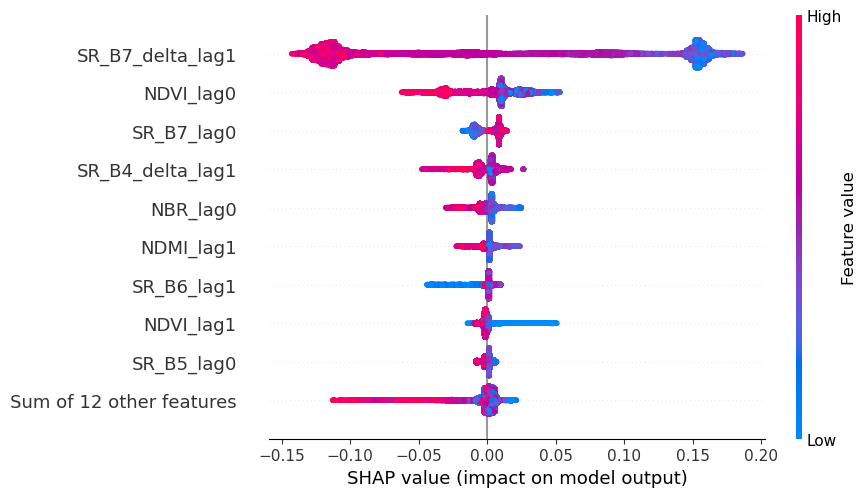

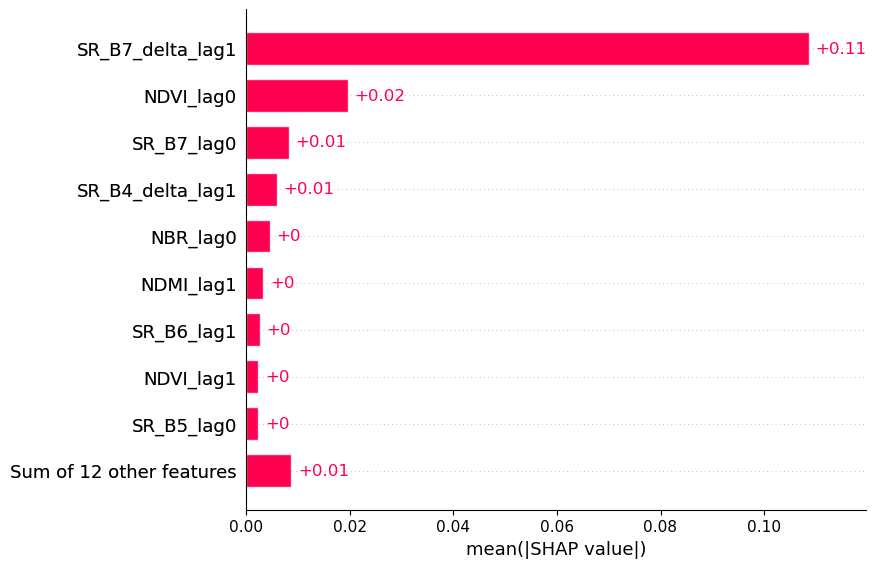

In [25]:
import shap
explainer = shap.Explainer(final_pipe['model'])
# Transform training data for the model component
X_trans = pd.DataFrame(
    final_pipe.named_steps['transformer'].transform(X_train),
    columns=recent_features,
    index=X_train.index,
)
shap_values = explainer(X_trans)
# visualize explanations
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)


In [26]:
print(len(X))

54000


# Test On Holdout Set From the Same Region

In [27]:
sweden_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/boreal/sweden_test_2025.csv"), 2025)
quebec_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/types/boreal/quebec_test_2025.csv"), 2025)
siberia_test = prepare_data(pd.read_csv("datasets/post_pivot/plus_one/expanded_class/types/boreal/siberia_test_2025.csv"), 2025)

print(len(sweden_test))
print(len(quebec_test))
print(len(siberia_test))


6000
6000
6000


In [28]:
X_test_sweden = sweden_test[recent_features]
y_test_sweden = sweden_test['class']
X_test_quebec = quebec_test[recent_features]
y_test_quebec = quebec_test['class']
X_test_siberia = siberia_test[recent_features]
y_test_siberia = siberia_test['class']
print(y_test_quebec.value_counts())

class
0    3000
1    3000
Name: count, dtype: int64


In [29]:
from sklearn.metrics import precision_score, recall_score

print("sweden Test")
y_test_sweden_pred = final_pipe.predict(X_test_sweden)
print(f"f1: {f1_score(y_test_sweden, y_test_sweden_pred)}")
print(f"precision: {precision_score(y_test_sweden, y_test_sweden_pred)}")
print(f"recall: {recall_score(y_test_sweden, y_test_sweden_pred)}")

print("siberia Test")
y_test_siberia_pred = final_pipe.predict(X_test_siberia)
print(f"f1: {f1_score(y_test_siberia, y_test_siberia_pred)}")
print(f"precision: {precision_score(y_test_siberia, y_test_siberia_pred)}")
print(f"recall: {recall_score(y_test_siberia, y_test_siberia_pred)}")

print("quebec Test")
y_test_quebec_pred = final_pipe.predict(X_test_quebec)
print(f"f1: {f1_score(y_test_quebec, y_test_quebec_pred)}")
print(f"precision: {precision_score(y_test_quebec, y_test_quebec_pred)}")
print(f"recall: {recall_score(y_test_quebec, y_test_quebec_pred)}")

print("All Together Test")
X_test = pd.concat([X_test_sweden, X_test_siberia, X_test_quebec])
y_test = pd.concat([y_test_sweden, y_test_siberia, y_test_quebec])
y_test_pred = final_pipe.predict(X_test)
print(f"f1: {f1_score(y_test, y_test_pred)}")
print(f"precision: {precision_score(y_test, y_test_pred)}")
print(f"recall: {recall_score(y_test, y_test_pred)}")

sweden Test
f1: 0.9121352785145889
precision: 0.9073218997361477
recall: 0.917
siberia Test
f1: 0.8736861515766181
precision: 0.977713578208832
recall: 0.7896666666666666
quebec Test
f1: 0.7849019284654689
precision: 0.7763286599282687
recall: 0.7936666666666666
All Together Test
f1: 0.8561808012783929
precision: 0.8801924430884769
recall: 0.8334444444444444


# Test on New Regions

In [30]:
alaska_test = prepare_data(pd.read_csv(f"datasets/post_pivot/plus_one/expanded_class/types/boreal/alaska_test_2025.csv"), 2025)

In [31]:
X_test_alaska = alaska_test[recent_features]
y_test_alaska = alaska_test['class']
print(y_test_alaska.value_counts())

class
1    3000
0    3000
Name: count, dtype: int64


In [32]:
print("alaska Test")
y_test_alaska_pred = final_pipe.predict(X_test_alaska)
print(f"f1: {f1_score(y_test_alaska, y_test_alaska_pred)}")
print(f"precision: {precision_score(y_test_alaska, y_test_alaska_pred)}")
print(f"recall: {recall_score(y_test_alaska, y_test_alaska_pred)}")


alaska Test
f1: 0.7064797887466991
precision: 0.9043161726469059
recall: 0.5796666666666667


boreal model succeeds, though not quite as good on the alaska...